# Figure 4

Survival analysis — KM by cancer group (A/B), variable × outcome status (C/D), mini-KM (E/F), TF=1 bias sensitivity (G), stratified Cox forest plots (H/I), and per-cancer-group univariate Cox (J/K)

4.A


Cancer groups with complete OS: 52
Tested vs others (N>=20): 22 | plotted: 15
FDR<0.05 vs all others: 15/22 OS


global OS log-rank p=0.0000


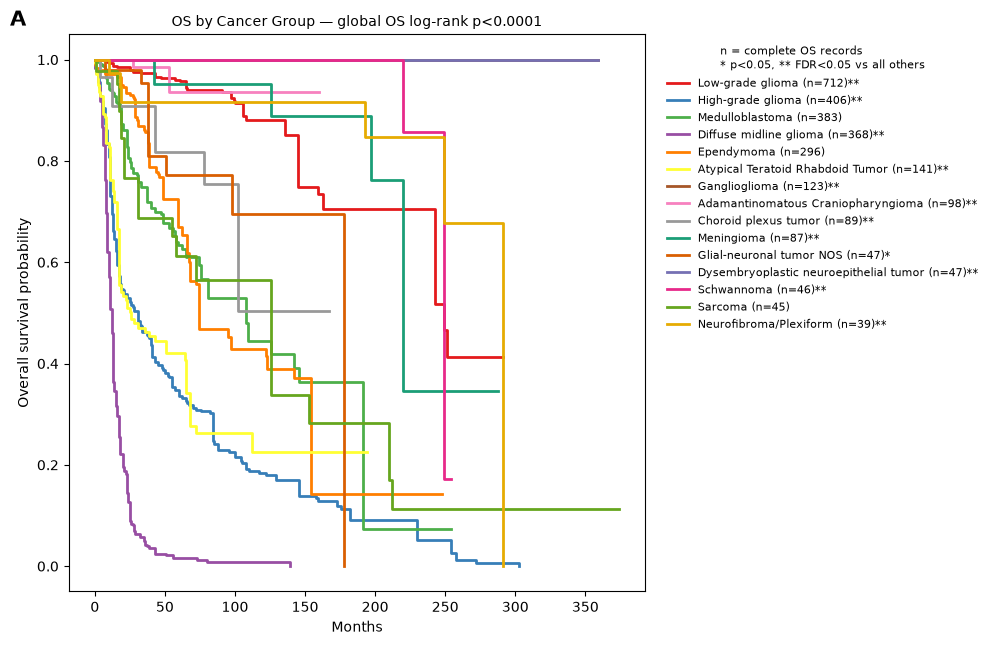

In [1]:
# Panel 4.A — OS by Cancer Group (context/figure_instructions/fig_survival_analysis.md)
# Reuses clinical_analysis/src/step_12.py: per-group log-rank vs all others + BH-FDR.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.A")

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    if n == 0:
        return np.array([])
    order = np.argsort(pvals)
    adj = pvals[order] * n / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(adj, 0, 1)
    return out

def legend_sig(p, q):
    if q < 0.05: return "**"
    if p < 0.05: return "*"
    return ""

osd = df[["CANCER_GROUP", "OS_MONTHS", "os_event"]].dropna()
os_n = osd.groupby("CANCER_GROUP").size().sort_values(ascending=False)
MIN_N, MAX_PLOT = 20, 15
test_groups = os_n[os_n >= MIN_N].index.tolist()
plot_groups = os_n[os_n >= MIN_N].head(MAX_PLOT).index.tolist()
os_p = {g: logrank2(osd.loc[osd["CANCER_GROUP"] == g, "OS_MONTHS"],
                     osd.loc[osd["CANCER_GROUP"] == g, "os_event"],
                     osd.loc[osd["CANCER_GROUP"] != g, "OS_MONTHS"],
                     osd.loc[osd["CANCER_GROUP"] != g, "os_event"])
        for g in test_groups}
os_q = dict(zip(test_groups, bh_fdr([os_p[g] for g in test_groups])))
print(f"Cancer groups with complete OS: {len(os_n)}")
print(f"Tested vs others (N>={MIN_N}): {len(test_groups)} | plotted: {len(plot_groups)}")
print(f"FDR<0.05 vs all others: {sum(1 for g in test_groups if os_q[g] < 0.05)}/{len(test_groups)} OS")

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#ffff33",
          "#a65628", "#f781bf", "#999999", "#1b9e77", "#d95f02", "#7570b3",
          "#e7298a", "#66a61e", "#e6ab02"]
fig, ax = plt.subplots(figsize=(10, 6.5))
os_d = []
for i, cg in enumerate(plot_groups):
    sub = df[df["CANCER_GROUP"] == cg]
    os_s = sub[["OS_MONTHS", "os_event"]].dropna()
    label = f"{cg} (n={len(os_s)}){legend_sig(os_p.get(cg, 1.0), os_q.get(cg, 1.0))}"
    km = kaplan_meier(os_s["OS_MONTHS"], os_s["os_event"])
    plot_km(ax, km, colors[i % len(colors)], lw=2, label=label)
    os_d.append((os_s["OS_MONTHS"], os_s["os_event"]))
po = logrank_multi(os_d)
print(f"global OS log-rank p={po:.4f}")
anno = "global OS log-rank p<0.0001" if po < 0.0001 else f"global OS log-rank p={po:.4f}"
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Months")
ax.set_ylabel("Overall survival probability")
ax.set_title(f"OS by Cancer Group — {anno}", fontsize=10)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=False,
          title="n = complete OS records\n* p<0.05, ** FDR<0.05 vs all others", title_fontsize=8)
fig.text(0.008, 0.985, "A", fontsize=15, fontweight="bold", va="top", ha="left",
         bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=0.5))
fig.tight_layout()
plt.show()


4.B


Cancer groups with complete EFS: 52
Tested vs others (N>=20): 22 EFS
FDR<0.05 vs all others: 16/22 EFS


global EFS log-rank p=0.0000


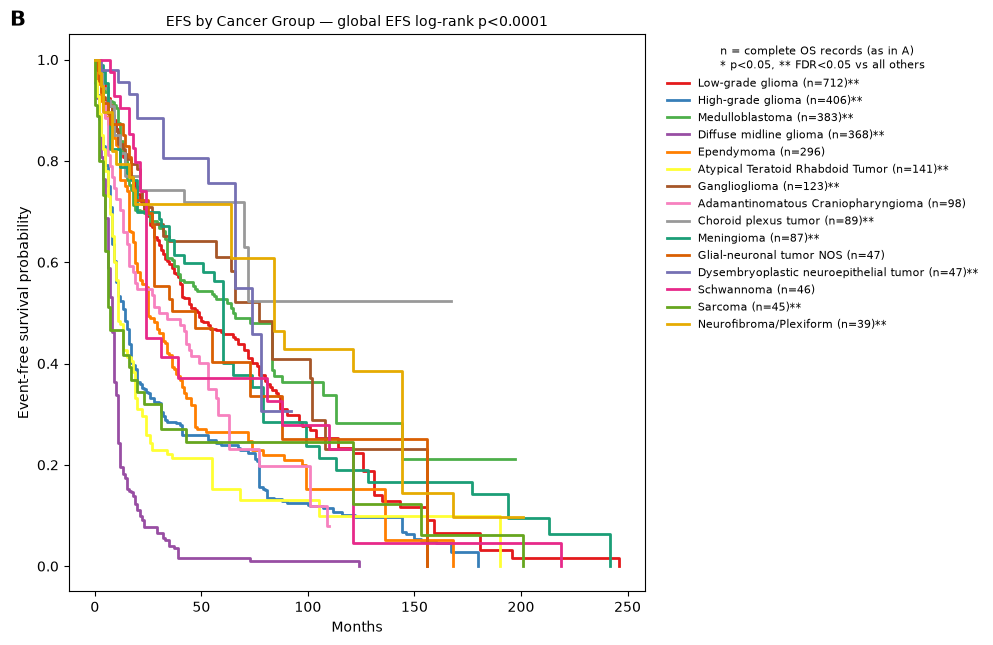

In [2]:
# Panel 4.B — EFS by Cancer Group (context/figure_instructions/fig_survival_analysis.md)
# Reuses step_12.py EFS; same 15 plotted CGs and colors as A.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.B")

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    if n == 0:
        return np.array([])
    order = np.argsort(pvals)
    adj = pvals[order] * n / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(n); out[order] = np.clip(adj, 0, 1)
    return out

def legend_sig(p, q):
    if q < 0.05: return "**"
    if p < 0.05: return "*"
    return ""

osd = df[["CANCER_GROUP", "OS_MONTHS", "os_event"]].dropna()
os_n = osd.groupby("CANCER_GROUP").size().sort_values(ascending=False)
MIN_N, MAX_PLOT = 20, 15
plot_groups = os_n[os_n >= MIN_N].head(MAX_PLOT).index.tolist()
efd = df[["CANCER_GROUP", "EFS_MONTHS", "efs_event"]].dropna()
ef_n = efd.groupby("CANCER_GROUP").size().sort_values(ascending=False)
test_groups = ef_n[ef_n >= MIN_N].index.tolist()
ef_p = {g: logrank2(efd.loc[efd["CANCER_GROUP"] == g, "EFS_MONTHS"],
                     efd.loc[efd["CANCER_GROUP"] == g, "efs_event"],
                     efd.loc[efd["CANCER_GROUP"] != g, "EFS_MONTHS"],
                     efd.loc[efd["CANCER_GROUP"] != g, "efs_event"])
        for g in test_groups}
ef_q = dict(zip(test_groups, bh_fdr([ef_p[g] for g in test_groups])))
print(f"Cancer groups with complete EFS: {len(ef_n)}")
print(f"Tested vs others (N>={MIN_N}): {len(test_groups)} EFS")
print(f"FDR<0.05 vs all others: {sum(1 for g in test_groups if ef_q[g] < 0.05)}/{len(test_groups)} EFS")

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#ffff33",
          "#a65628", "#f781bf", "#999999", "#1b9e77", "#d95f02", "#7570b3",
          "#e7298a", "#66a61e", "#e6ab02"]
fig, ax = plt.subplots(figsize=(10, 6.5))
ef_d = []
for i, cg in enumerate(plot_groups):
    sub = df[df["CANCER_GROUP"] == cg]
    os_s = sub[["OS_MONTHS", "os_event"]].dropna()
    ef_s = sub[["EFS_MONTHS", "efs_event"]].dropna()
    label = f"{cg} (n={len(os_s)}){legend_sig(ef_p.get(cg, 1.0), ef_q.get(cg, 1.0))}"
    km = kaplan_meier(ef_s["EFS_MONTHS"], ef_s["efs_event"])
    plot_km(ax, km, colors[i % len(colors)], lw=2, label=label)
    ef_d.append((ef_s["EFS_MONTHS"], ef_s["efs_event"]))
pe = logrank_multi(ef_d)
print(f"global EFS log-rank p={pe:.4f}")
anno = "global EFS log-rank p<0.0001" if pe < 0.0001 else f"global EFS log-rank p={pe:.4f}"
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Months")
ax.set_ylabel("Event-free survival probability")
ax.set_title(f"EFS by Cancer Group — {anno}", fontsize=10)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=False,
          title="n = complete OS records (as in A)\n* p<0.05, ** FDR<0.05 vs all others", title_fontsize=8)
fig.text(0.008, 0.985, "B", fontsize=15, fontweight="bold", va="top", ha="left",
         bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=0.5))
fig.tight_layout()
plt.show()


4.C


AGE x OS: U=1653162 p=0.0183 d=0.047 N=3714


TUMOR_FRACTION x OS: U=864204 p=0.0000 d=0.133 N=2567


TUMOR_PLOIDY x OS: U=766936 p=0.0997 d=-0.031 N=2621
SEX x OS: chi2=15.27 p=0.0016 V=0.064 N=3718
Verify C: AGE U=1819966 p=0.0059 d=0.053; TF U=957930 p<0.001 d=0.149; TP U=837216 p=0.0772 d=-0.033; SEX chi2=10.35 p=0.0057 V=0.052


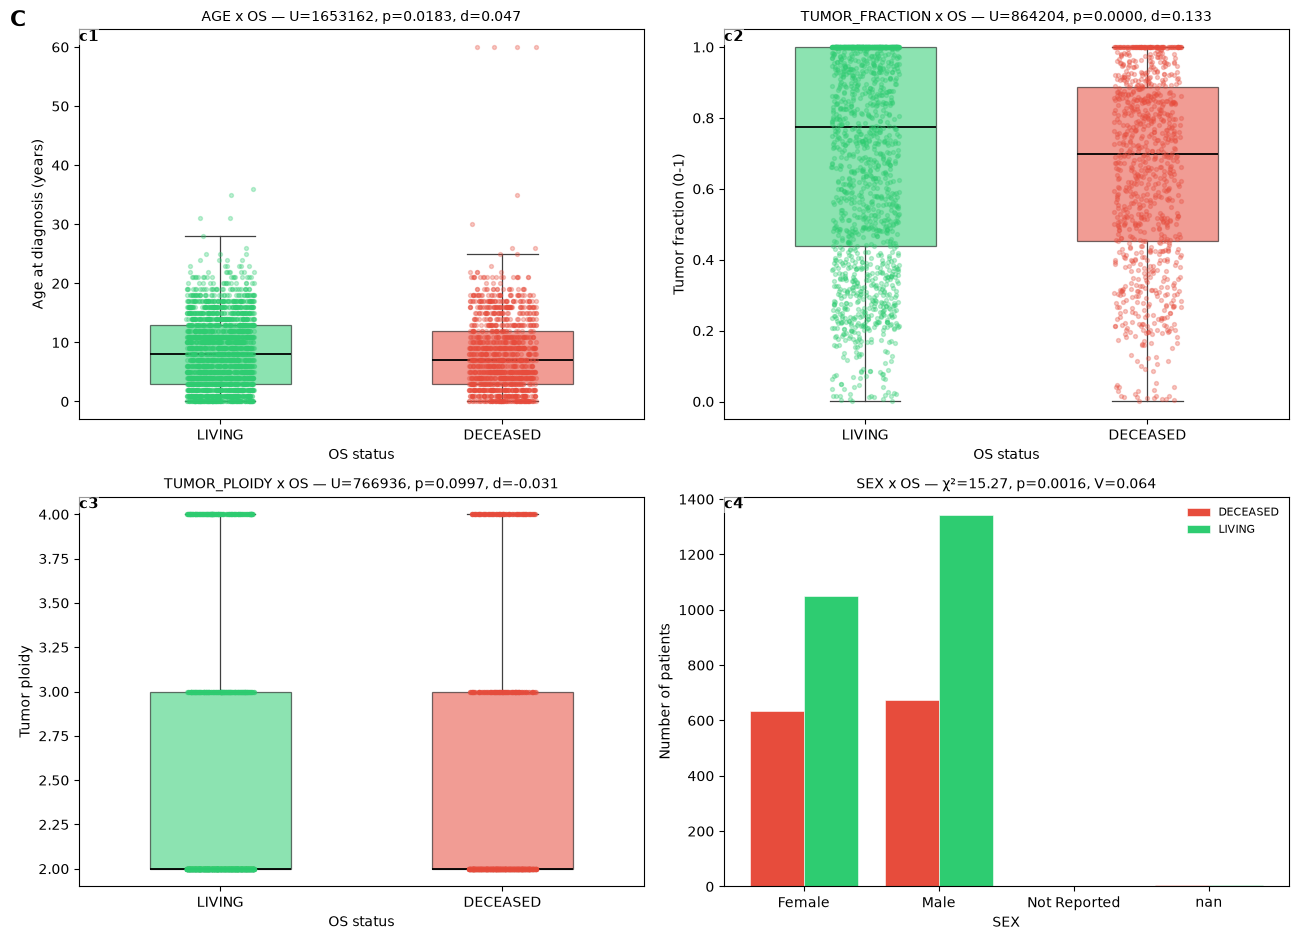

In [3]:
# Panel 4.C — Variable × OS status (global, binary) (context/figure_instructions/fig_survival_analysis.md)
# Reuses survival_analysis.ipynb 1A.1/1B.1/1C.1/1D.1.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.C")
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
fig.text(0.005, 0.985, "C", fontsize=16, fontweight="bold", va="top", ha="left")
status_box(axes[0, 0], "AGE", "Age at diagnosis (years)", "OS")
status_box(axes[0, 1], "TUMOR_FRACTION", "Tumor fraction (0-1)", "OS")
status_box(axes[1, 0], "TUMOR_PLOIDY", "Tumor ploidy", "OS")
sex_bar(axes[1, 1], "OS")
for ax, lbl in zip(axes.ravel(), ["c1", "c2", "c3", "c4"]):
    ax.text(0.0, 1.0, lbl, transform=ax.transAxes, fontsize=11, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
print("Verify C: AGE U=1819966 p=0.0059 d=0.053; TF U=957930 p<0.001 d=0.149; "
      "TP U=837216 p=0.0772 d=-0.033; SEX chi2=10.35 p=0.0057 V=0.052")
fig.tight_layout()
plt.show()


4.D


AGE x EFS: U=1862490 p=0.0000 d=0.157 N=3647


TUMOR_FRACTION x EFS: U=836410 p=0.0004 d=0.081 N=2515


TUMOR_PLOIDY x EFS: U=784738 p=0.0919 d=-0.031 N=2570
SEX x EFS: chi2=10.49 p=0.0148 V=0.054 N=3652
Verify D: AGE U=2081908 p<0.001 d=0.161; TF U=940892 p<0.001 d=0.094; TP U=868710 p=0.0454 d=-0.036; SEX chi2=5.81 p=0.0548 V=0.039


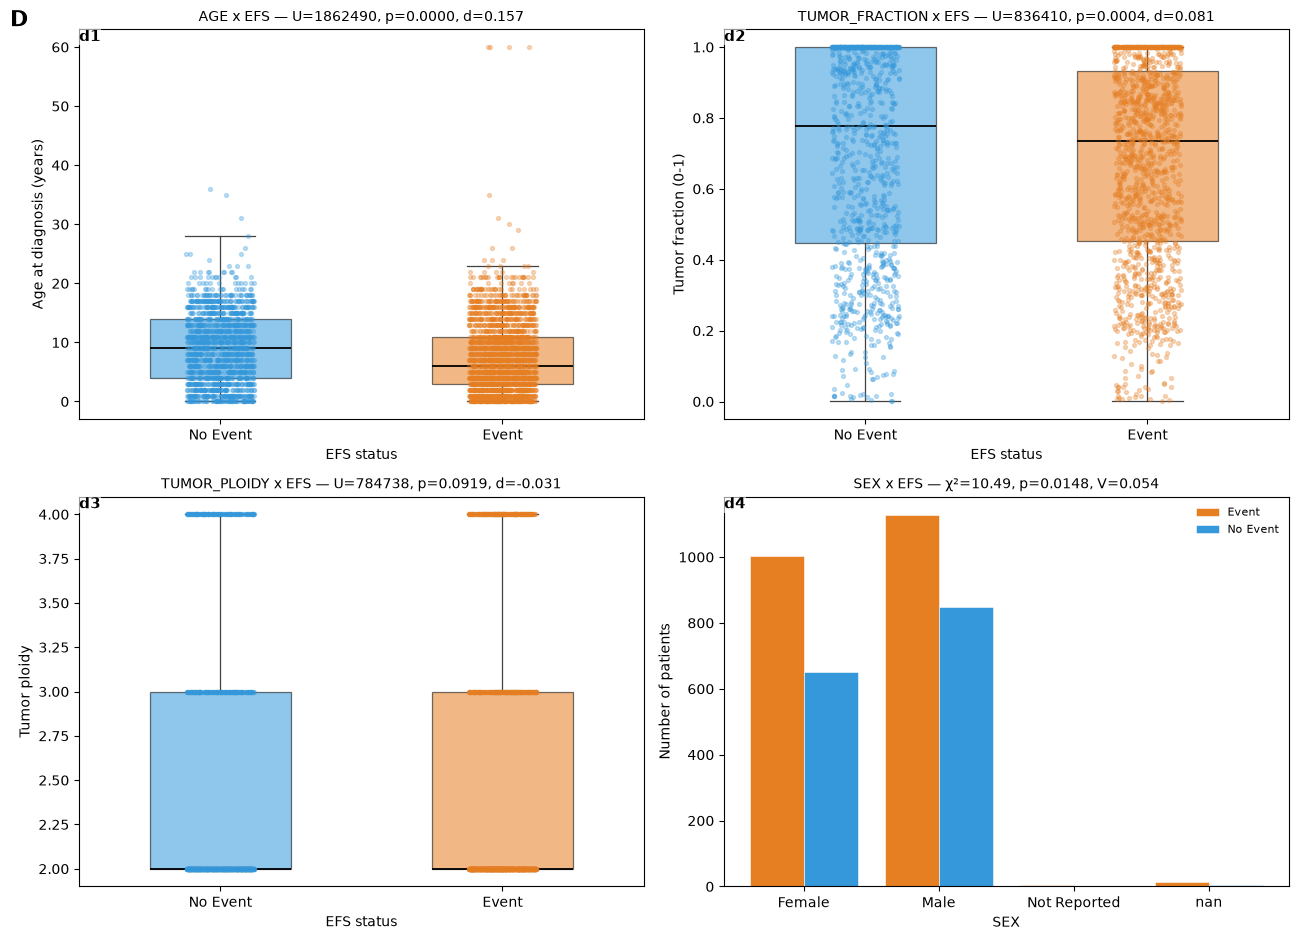

In [4]:
# Panel 4.D — Variable × EFS status (global, binary) (context/figure_instructions/fig_survival_analysis.md)
# Reuses survival_analysis.ipynb 1A.2/1B.2/1C.2/1D.2.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.D")
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
fig.text(0.005, 0.985, "D", fontsize=16, fontweight="bold", va="top", ha="left")
status_box(axes[0, 0], "AGE", "Age at diagnosis (years)", "EFS")
status_box(axes[0, 1], "TUMOR_FRACTION", "Tumor fraction (0-1)", "EFS")
status_box(axes[1, 0], "TUMOR_PLOIDY", "Tumor ploidy", "EFS")
sex_bar(axes[1, 1], "EFS")
for ax, lbl in zip(axes.ravel(), ["d1", "d2", "d3", "d4"]):
    ax.text(0.0, 1.0, lbl, transform=ax.transAxes, fontsize=11, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
print("Verify D: AGE U=2081908 p<0.001 d=0.161; TF U=940892 p<0.001 d=0.094; "
      "TP U=868710 p=0.0454 d=-0.036; SEX chi2=5.81 p=0.0548 V=0.039")
fig.tight_layout()
plt.show()


4.E


AGE x OS (KM): log-rank p=0.0910 (median split at 7y)


TF x OS (KM): log-rank p=0.0067 (median split at 0.73)


TP x OS (KM): log-rank p=0.0574 (diploid vs aneuploid)


SEX x OS (KM): log-rank p=0.0010


Pred x OS (KM): log-rank p=0.0049
Verify E: AGE p=0.0997 (ns); TF p=0.0028; TP p=0.0664 (ns); SEX p=0.0032; pred p=0.0019


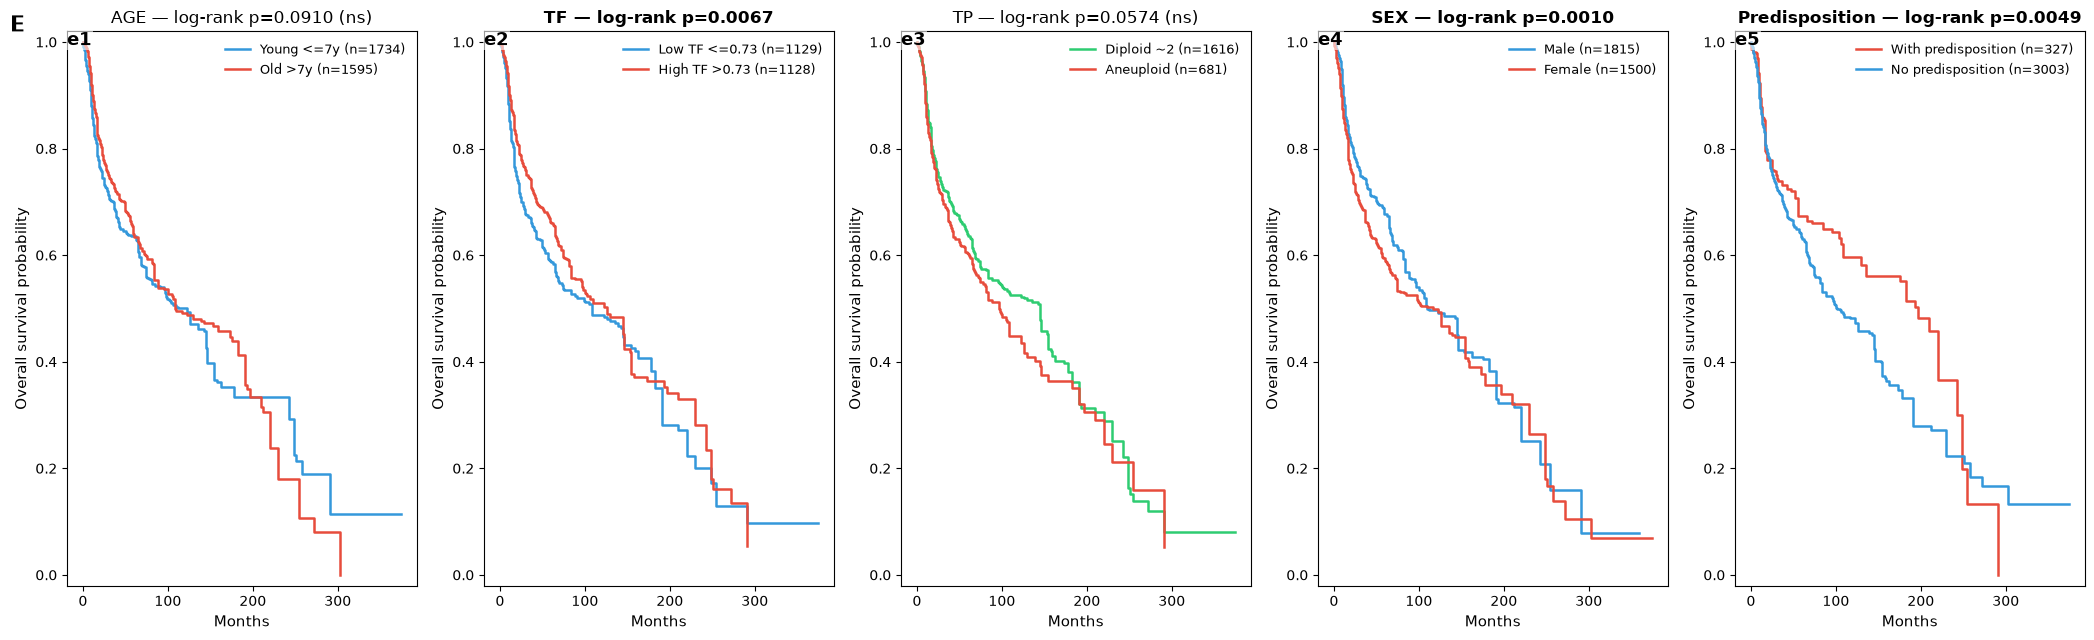

In [5]:
# Panel 4.E — Mini KM — OS (context/figure_instructions/fig_survival_analysis.md)
# Reuses survival_analysis.ipynb 1A.3/1B.3/1C.3/1D.3/1E.1.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.E")
fig, axes = plt.subplots(1, 5, figsize=(21, 6.5))
fig.text(0.005, 0.97, "E", fontsize=16, fontweight="bold", va="top", ha="left")
T, E, ylab = "OS_MONTHS", "os_event", "Overall survival probability"

d = df.dropna(subset=["AGE", T, E]).copy()
med = d["AGE"].median()
p = km_mini(axes[0], d[d["AGE"] <= med], d[d["AGE"] > med], T, E,
            f"Young <={med:.0f}y", f"Old >{med:.0f}y", "#3498db", "#e74c3c",
            "AGE", "e1", ylab)
print(f"AGE x OS (KM): log-rank p={p:.4f} (median split at {med:.0f}y)")

d = df.dropna(subset=["TUMOR_FRACTION", T, E]).copy()
med = d["TUMOR_FRACTION"].median()
p = km_mini(axes[1], d[d["TUMOR_FRACTION"] <= med], d[d["TUMOR_FRACTION"] > med], T, E,
            f"Low TF <={med:.2f}", f"High TF >{med:.2f}", "#3498db", "#e74c3c",
            "TF", "e2", ylab)
print(f"TF x OS (KM): log-rank p={p:.4f} (median split at {med:.2f})")

d = df.dropna(subset=["TUMOR_PLOIDY", T, E]).copy()
dip = d[(d["TUMOR_PLOIDY"] >= 1.8) & (d["TUMOR_PLOIDY"] <= 2.2)]
aneu = d[~((d["TUMOR_PLOIDY"] >= 1.8) & (d["TUMOR_PLOIDY"] <= 2.2))]
p = km_mini(axes[2], dip, aneu, T, E, "Diploid ~2", "Aneuploid", "#2ecc71", "#e74c3c",
            "TP", "e3", ylab)
print(f"TP x OS (KM): log-rank p={p:.4f} (diploid vs aneuploid)")

d = df.dropna(subset=["SEX", T, E]).copy()
p = km_mini(axes[3], d[d["SEX"] == "Male"], d[d["SEX"] == "Female"], T, E,
            "Male", "Female", "#3498db", "#e74c3c", "SEX", "e4", ylab)
print(f"SEX x OS (KM): log-rank p={p:.4f}")

d = df.dropna(subset=[T, E]).copy()
d["has_pred"] = ~d["CANCER_PREDISPOSITIONS"].isin(["No predisposition", "Unknown"])
p = km_mini(axes[4], d[d["has_pred"]], d[~d["has_pred"]], T, E,
            "With predisposition", "No predisposition", "#e74c3c", "#3498db",
            "Predisposition", "e5", ylab)
print(f"Pred x OS (KM): log-rank p={p:.4f}")

print("Verify E: AGE p=0.0997 (ns); TF p=0.0028; TP p=0.0664 (ns); SEX p=0.0032; pred p=0.0019")
fig.tight_layout()
plt.show()


4.F


AGE x EFS (KM): log-rank p=0.0000 (median split at 7y)


TF x EFS (KM): log-rank p=0.6313 (median split at 0.74)


TP x EFS (KM): log-rank p=0.0671 (diploid vs aneuploid)


SEX x EFS (KM): log-rank p=0.0001


Pred x EFS (KM): log-rank p=0.2098
Verify F: AGE p<0.001; TF p=0.5201 (ns); TP p=0.0555 (ns); SEX p=0.0001; pred p=0.5678 (ns)


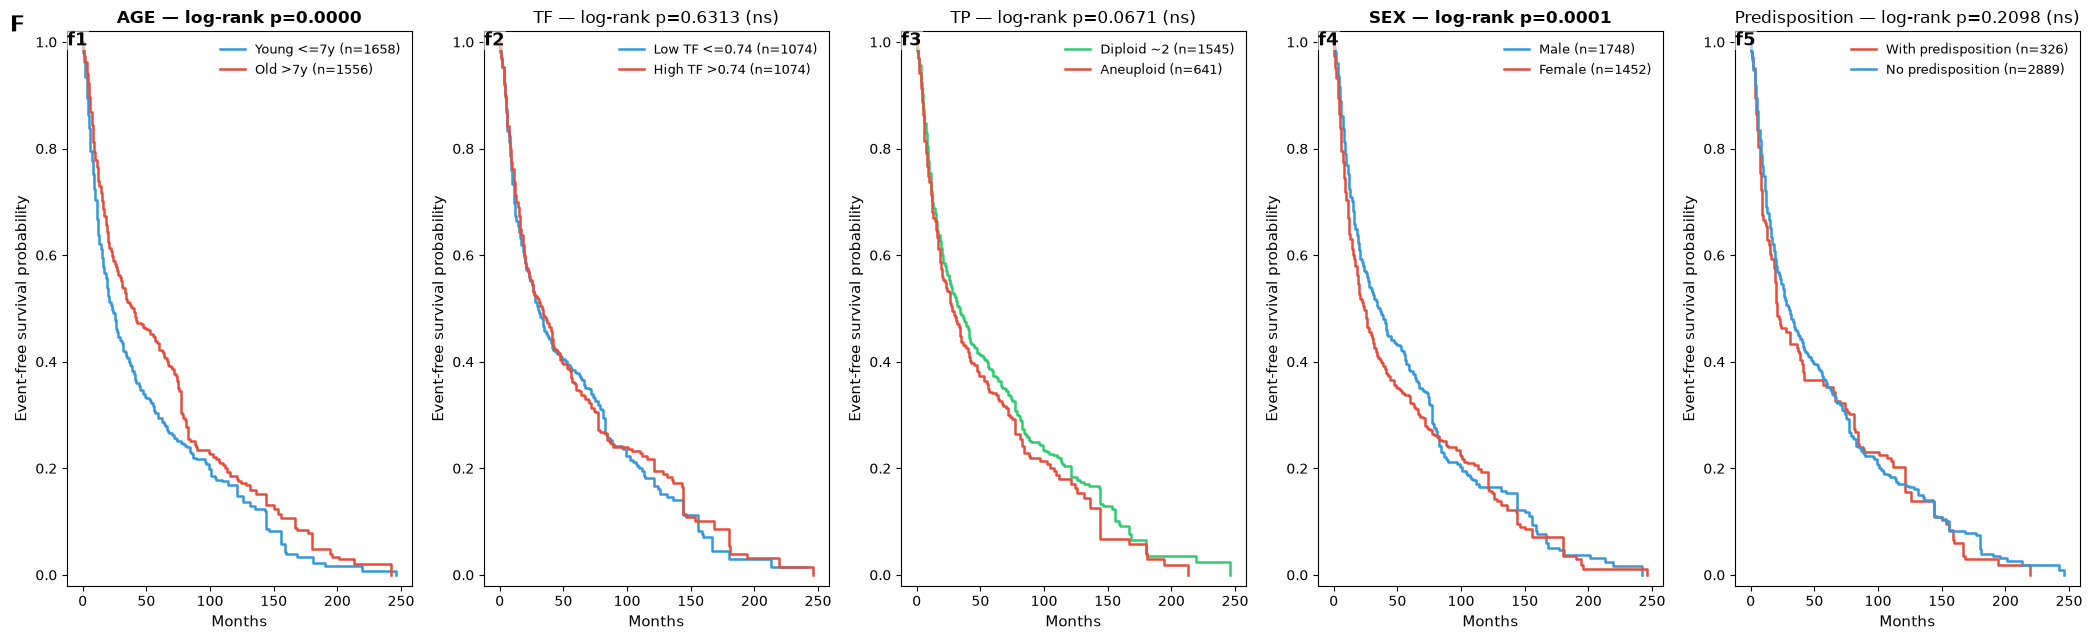

In [6]:
# Panel 4.F — Mini KM — EFS (context/figure_instructions/fig_survival_analysis.md)
# Reuses survival_analysis.ipynb 1A.4/1B.4/1C.4/1D.4/1E.2.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.F")
fig, axes = plt.subplots(1, 5, figsize=(21, 6.5))
fig.text(0.005, 0.97, "F", fontsize=16, fontweight="bold", va="top", ha="left")
T, E, ylab = "EFS_MONTHS", "efs_event", "Event-free survival probability"

d = df.dropna(subset=["AGE", T, E]).copy()
med = d["AGE"].median()
p = km_mini(axes[0], d[d["AGE"] <= med], d[d["AGE"] > med], T, E,
            f"Young <={med:.0f}y", f"Old >{med:.0f}y", "#3498db", "#e74c3c",
            "AGE", "f1", ylab)
print(f"AGE x EFS (KM): log-rank p={p:.4f} (median split at {med:.0f}y)")

d = df.dropna(subset=["TUMOR_FRACTION", T, E]).copy()
med = d["TUMOR_FRACTION"].median()
p = km_mini(axes[1], d[d["TUMOR_FRACTION"] <= med], d[d["TUMOR_FRACTION"] > med], T, E,
            f"Low TF <={med:.2f}", f"High TF >{med:.2f}", "#3498db", "#e74c3c",
            "TF", "f2", ylab)
print(f"TF x EFS (KM): log-rank p={p:.4f} (median split at {med:.2f})")

d = df.dropna(subset=["TUMOR_PLOIDY", T, E]).copy()
dip = d[(d["TUMOR_PLOIDY"] >= 1.8) & (d["TUMOR_PLOIDY"] <= 2.2)]
aneu = d[~((d["TUMOR_PLOIDY"] >= 1.8) & (d["TUMOR_PLOIDY"] <= 2.2))]
p = km_mini(axes[2], dip, aneu, T, E, "Diploid ~2", "Aneuploid", "#2ecc71", "#e74c3c",
            "TP", "f3", ylab)
print(f"TP x EFS (KM): log-rank p={p:.4f} (diploid vs aneuploid)")

d = df.dropna(subset=["SEX", T, E]).copy()
p = km_mini(axes[3], d[d["SEX"] == "Male"], d[d["SEX"] == "Female"], T, E,
            "Male", "Female", "#3498db", "#e74c3c", "SEX", "f4", ylab)
print(f"SEX x EFS (KM): log-rank p={p:.4f}")

d = df.dropna(subset=[T, E]).copy()
d["has_pred"] = ~d["CANCER_PREDISPOSITIONS"].isin(["No predisposition", "Unknown"])
p = km_mini(axes[4], d[d["has_pred"]], d[~d["has_pred"]], T, E,
            "With predisposition", "No predisposition", "#e74c3c", "#3498db",
            "Predisposition", "f5", ylab)
print(f"Pred x EFS (KM): log-rank p={p:.4f}")

print("Verify F: AGE p<0.001; TF p=0.5201 (ns); TP p=0.0555 (ns); SEX p=0.0001; pred p=0.5678 (ns)")
fig.tight_layout()
plt.show()


4.G


TUMOR_FRACTION x OS: U=864204 p=0.0000 d=0.133 N=2567


TF x OS (KM): log-rank p=0.0067 (median split at 0.73)
TF bin | n | deceased | death rate
             n  n_dec       rate
tf_bin                          
[0.0,0.1)   63     22  34.920635
[0.1,0.2)   74     27  36.486486
[0.2,0.3)  216     69  31.944444
[0.3,0.4)  213     72  33.802817
[0.4,0.5)  192     80  41.666667
[0.5,0.6)  214     96  44.859813
[0.6,0.7)  213    103  48.356808
[0.7,0.8)  239    113  47.280335
[0.8,0.9)  267    137  51.310861
[0.9,1.0)  276    115  41.666667
1.0        600    101  16.833333


TUMOR_FRACTION x OS: U=422839 p=0.0001 d=-0.105 N=1967
TF=1 samples (OS-known): 600, death rate 16.8%%
Peak death rate among TF<1 bins: 51.3%%


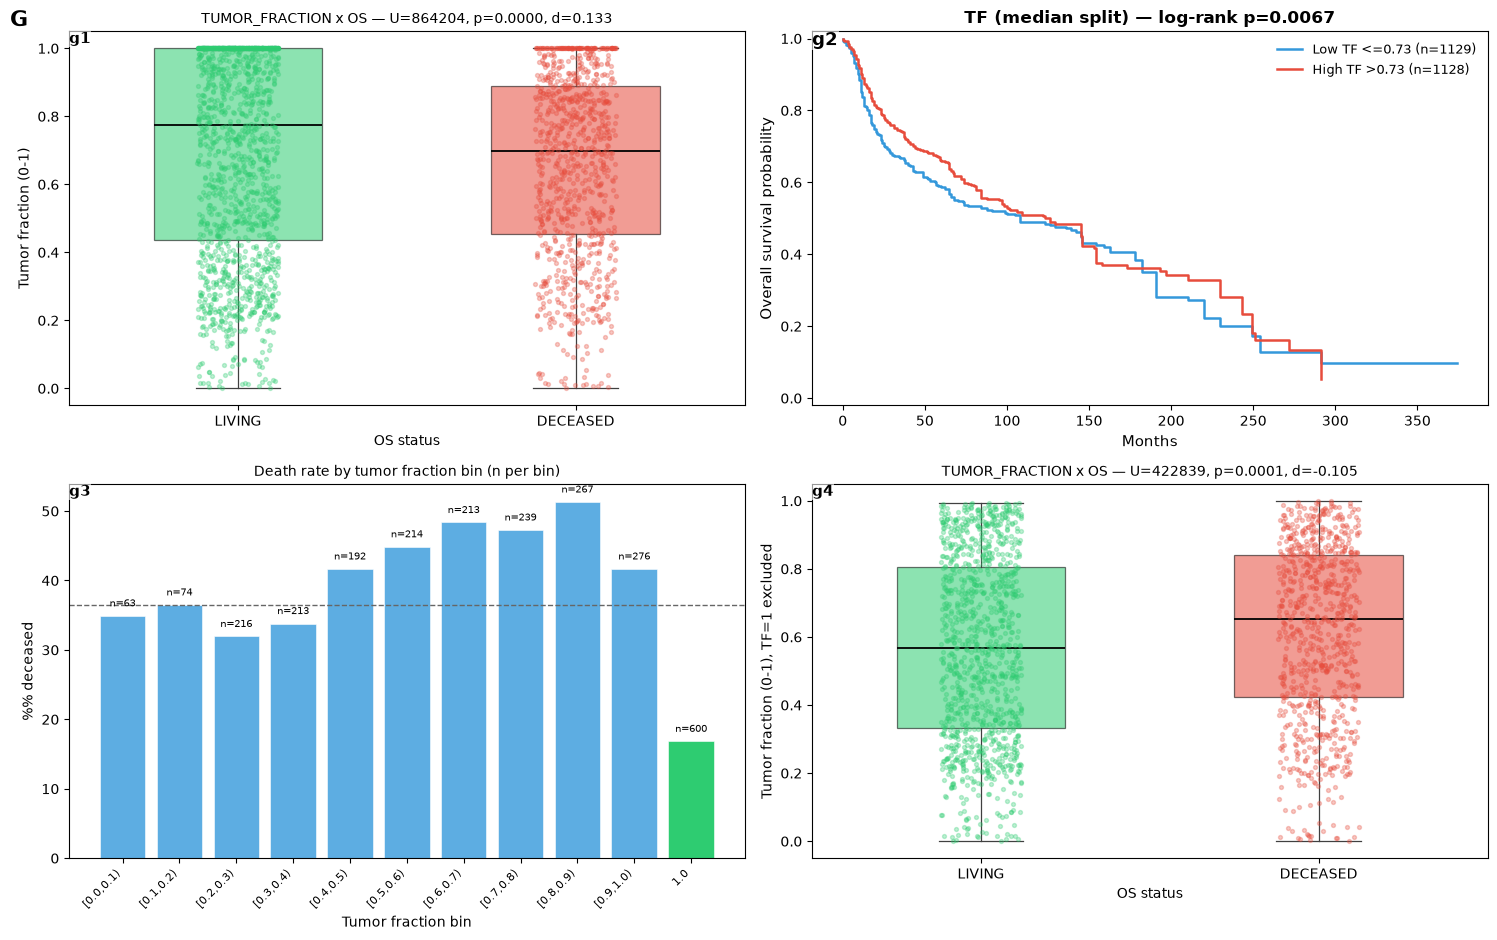

In [7]:
# Panel 4.G - TUMOR_FRACTION x OS: TF=1 bias sensitivity
# The TF-OS association is non-monotonic: death rate climbs toward ~50%% in the
# 0.7-0.9 bins, then collapses to ~16%% at TF=1 (661 OS-known samples), which biases
# the global Mann-Whitney. g1: global MW; g2: KM (median split); g3: binned death
# rate with n per bin; g4: MW sensitivity excluding TF=1.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.G")
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))
fig.text(0.005, 0.985, "G", fontsize=16, fontweight="bold", va="top", ha="left")

# g1 - TF x OS (global, binary MW)
status_box(axes[0, 0], "TUMOR_FRACTION", "Tumor fraction (0-1)", "OS")

# g2 - TF x OS (KM, median split)
T, E = "OS_MONTHS", "os_event"
d = df.dropna(subset=["TUMOR_FRACTION", T, E]).copy()
med = d["TUMOR_FRACTION"].median()
p = km_mini(axes[0, 1], d[d["TUMOR_FRACTION"] <= med], d[d["TUMOR_FRACTION"] > med], T, E,
            f"Low TF <={med:.2f}", f"High TF >{med:.2f}", "#3498db", "#e74c3c",
            "TF (median split)", "g2", "Overall survival probability")
print(f"TF x OS (KM): log-rank p={p:.4f} (median split at {med:.2f})")

# g3 - death rate by TF bin (n per bin); the ==1 bin kept separate
d = df.dropna(subset=["TUMOR_FRACTION", "OS_STATUS"]).copy()
d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
bins = [0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0]
blabels = [f"[{b:.1f},{b + .1:.1f})" for b in np.arange(0, 1, 0.1)]
d["tf_bin"] = pd.cut(d["TUMOR_FRACTION"], bins=bins, right=False, include_lowest=True,
                     labels=blabels, ordered=False)
d["tf_bin"] = d["tf_bin"].cat.add_categories("1.0").fillna("1.0")
tab = d.groupby("tf_bin", observed=False).agg(n=("TUMOR_FRACTION", "size"),
                                              n_dec=("os_label", lambda s: s.eq("DECEASED").sum()))
tab["rate"] = 100 * tab["n_dec"] / tab["n"]
tab = tab.reindex(blabels + ["1.0"])
print("TF bin | n | deceased | death rate")
print(tab.to_string())
ax = axes[1, 0]
cols = ["#5dade2"] * len(blabels) + ["#2ecc71"]
ax.bar(np.arange(len(tab)), tab["rate"], color=cols, edgecolor="white", lw=0.4)
ax.axhline(100 * d["os_label"].eq("DECEASED").mean(), color="0.4", ls="--", lw=1)
ax.set_xticks(np.arange(len(tab)))
ax.set_xticklabels(tab.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("%% deceased")
ax.set_xlabel("Tumor fraction bin")
ax.set_title("Death rate by tumor fraction bin (n per bin)", fontsize=10)
for xi, (n, r) in enumerate(zip(tab["n"], tab["rate"])):
    ax.text(xi, r + 1, f"n={n}", ha="center", va="bottom", fontsize=7.5)

# g4 - TF x OS (MW) excluding TF=1
status_box(axes[1, 1], "TUMOR_FRACTION", "Tumor fraction (0-1), TF=1 excluded", "OS",
           data=df[df["TUMOR_FRACTION"] < 1])

for ax, lbl in zip(axes.ravel(), ["g1", "g2", "g3", "g4"]):
    if lbl == "g2":
        continue  # km_mini already draws its subletter
    ax.text(0.0, 1.0, lbl, transform=ax.transAxes, fontsize=11, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
print(f"TF=1 samples (OS-known): {int((d['TUMOR_FRACTION'] == 1).sum())}, "
      f"death rate {tab.loc['1.0', 'rate']:.1f}%%")
print(f"Peak death rate among TF<1 bins: {tab['rate'].iloc[:-1].max():.1f}%%")
fig.tight_layout()
plt.show()


4.H


OS model: 2256 samples, 933 events
Concordance: 0.5642 | AIC: 7777.31
  AGE                  HR=0.9663 (0.9534-0.9793) p=0.0000
  SEX (Male)           HR=1.0687 (0.9321-1.2252) p=0.3411
  SEX (Not Reported)   HR=0.4493 (0.1113-1.8138) p=0.2611
  SEX (nan)            HR=0.8106 (0.3544-1.8542) p=0.6189
  TUMOR_FRACTION       HR=0.8434 (0.6600-1.0777) p=0.1732
  TUMOR_PLOIDY         HR=1.0094 (0.9234-1.1035) p=0.8361


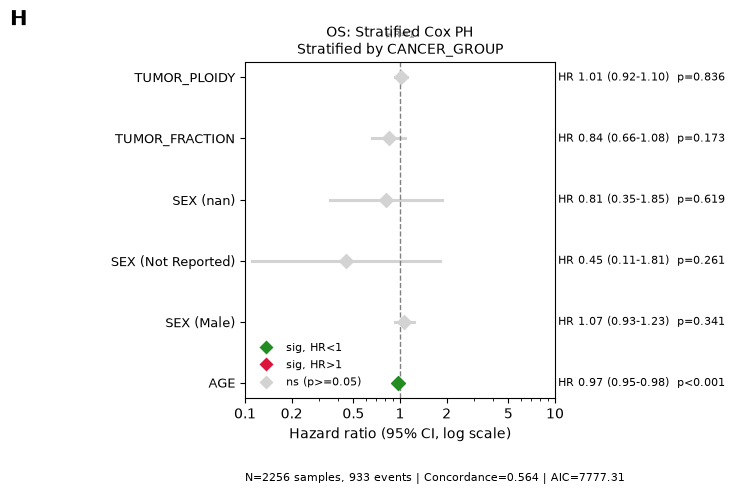

In [8]:
# Panel 4.H — Forest — OS (stratified Cox PH) (context/figure_instructions/fig_survival_analysis.md)
# Reuses clinical_mulltivar_hidden_strcture_analysis/src/build_nb.py cells 6+9.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")

from lifelines import CoxPHFitter

print("4.H")
os_df = df.dropna(subset=["OS_MONTHS", "os_event", "AGE", "SEX", "TUMOR_FRACTION", "TUMOR_PLOIDY"]).copy()
cph = CoxPHFitter(strata=["CANCER_GROUP"])
cph.fit(os_df, duration_col="OS_MONTHS", event_col="os_event",
        formula="AGE + C(SEX) + TUMOR_FRACTION + TUMOR_PLOIDY")
print(f"OS model: {len(os_df)} samples, {int(os_df['os_event'].sum())} events")
print(f"Concordance: {cph.concordance_index_:.4f} | AIC: {cph.AIC_partial_:.2f}")
forest_panel(cph, "OS: Stratified Cox PH",
             "N=2256 samples, 933 events | Concordance=0.564 | AIC=7777.31", "H")


4.I


EFS model: 2147 samples, 1384 events
Concordance: 0.5897 | AIC: 11145.77
  AGE                  HR=0.9570 (0.9465-0.9675) p=0.0000
  SEX (Male)           HR=0.9627 (0.8617-1.0756) p=0.5018
  SEX (Not Reported)   HR=0.2904 (0.0716-1.1776) p=0.0834
  SEX (nan)            HR=0.7748 (0.3575-1.6796) p=0.5181
  TUMOR_FRACTION       HR=1.0388 (0.8580-1.2577) p=0.6966
  TUMOR_PLOIDY         HR=1.0961 (1.0185-1.1796) p=0.0143


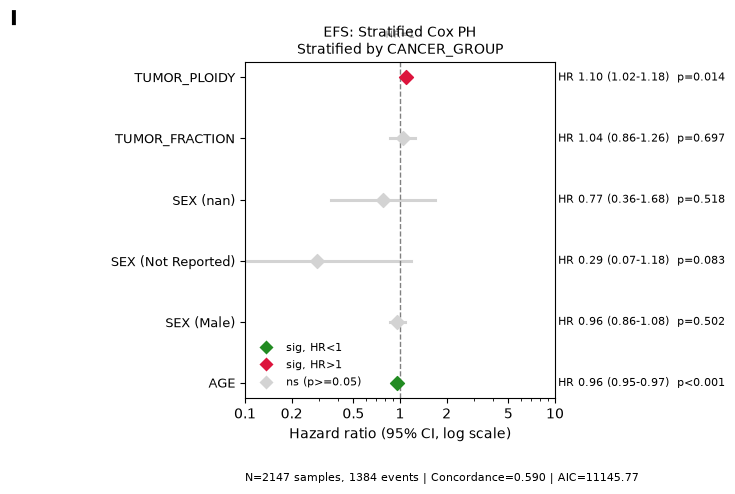

In [9]:
# Panel 4.I — Forest — EFS (stratified Cox PH) (context/figure_instructions/fig_survival_analysis.md)
# Reuses clinical_mulltivar_hidden_strcture_analysis/src/build_nb.py cells 8+10.
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")

from lifelines import CoxPHFitter

print("4.I")
efs_df = df.dropna(subset=["EFS_MONTHS", "efs_event", "AGE", "SEX", "TUMOR_FRACTION", "TUMOR_PLOIDY"]).copy()
cph = CoxPHFitter(strata=["CANCER_GROUP"])
cph.fit(efs_df, duration_col="EFS_MONTHS", event_col="efs_event",
        formula="AGE + C(SEX) + TUMOR_FRACTION + TUMOR_PLOIDY")
print(f"EFS model: {len(efs_df)} samples, {int(efs_df['efs_event'].sum())} events")
print(f"Concordance: {cph.concordance_index_:.4f} | AIC: {cph.AIC_partial_:.2f}")
forest_panel(cph, "EFS: Stratified Cox PH",
             "N=2147 samples, 1384 events | Concordance=0.590 | AIC=11145.77", "I")


4.J
OS per-CG univariate Cox: 2256 samples, 933 events


  [AGE] 18 CGs fitted, 4 significant:
    Medulloblastoma: HR=0.943 (0.907-0.981) p=0.0033 n=289 events=109
    High-grade glioma: HR=0.948 (0.927-0.969) p=0.0000 n=211 events=172
    Diffuse midline glioma: HR=0.975 (0.952-0.999) p=0.0420 n=326 events=317
    Glial-neuronal tumor NOS: HR=1.313 (1.078-1.599) p=0.0068 n=31 events=12


  [SEX] 19 CGs fitted, 2 significant:
    Ependymoma: HR=1.729 (1.087-2.749) p=0.0207 n=200 events=77
    Low-grade glioma: HR=2.281 (1.142-4.559) p=0.0196 n=440 events=44


  [TUMOR_FRACTION] 19 CGs fitted, 1 significant:
    Low-grade glioma: HR=0.312 (0.123-0.792) p=0.0143 n=440 events=44


  [TUMOR_PLOIDY] 19 CGs fitted, 0 significant:


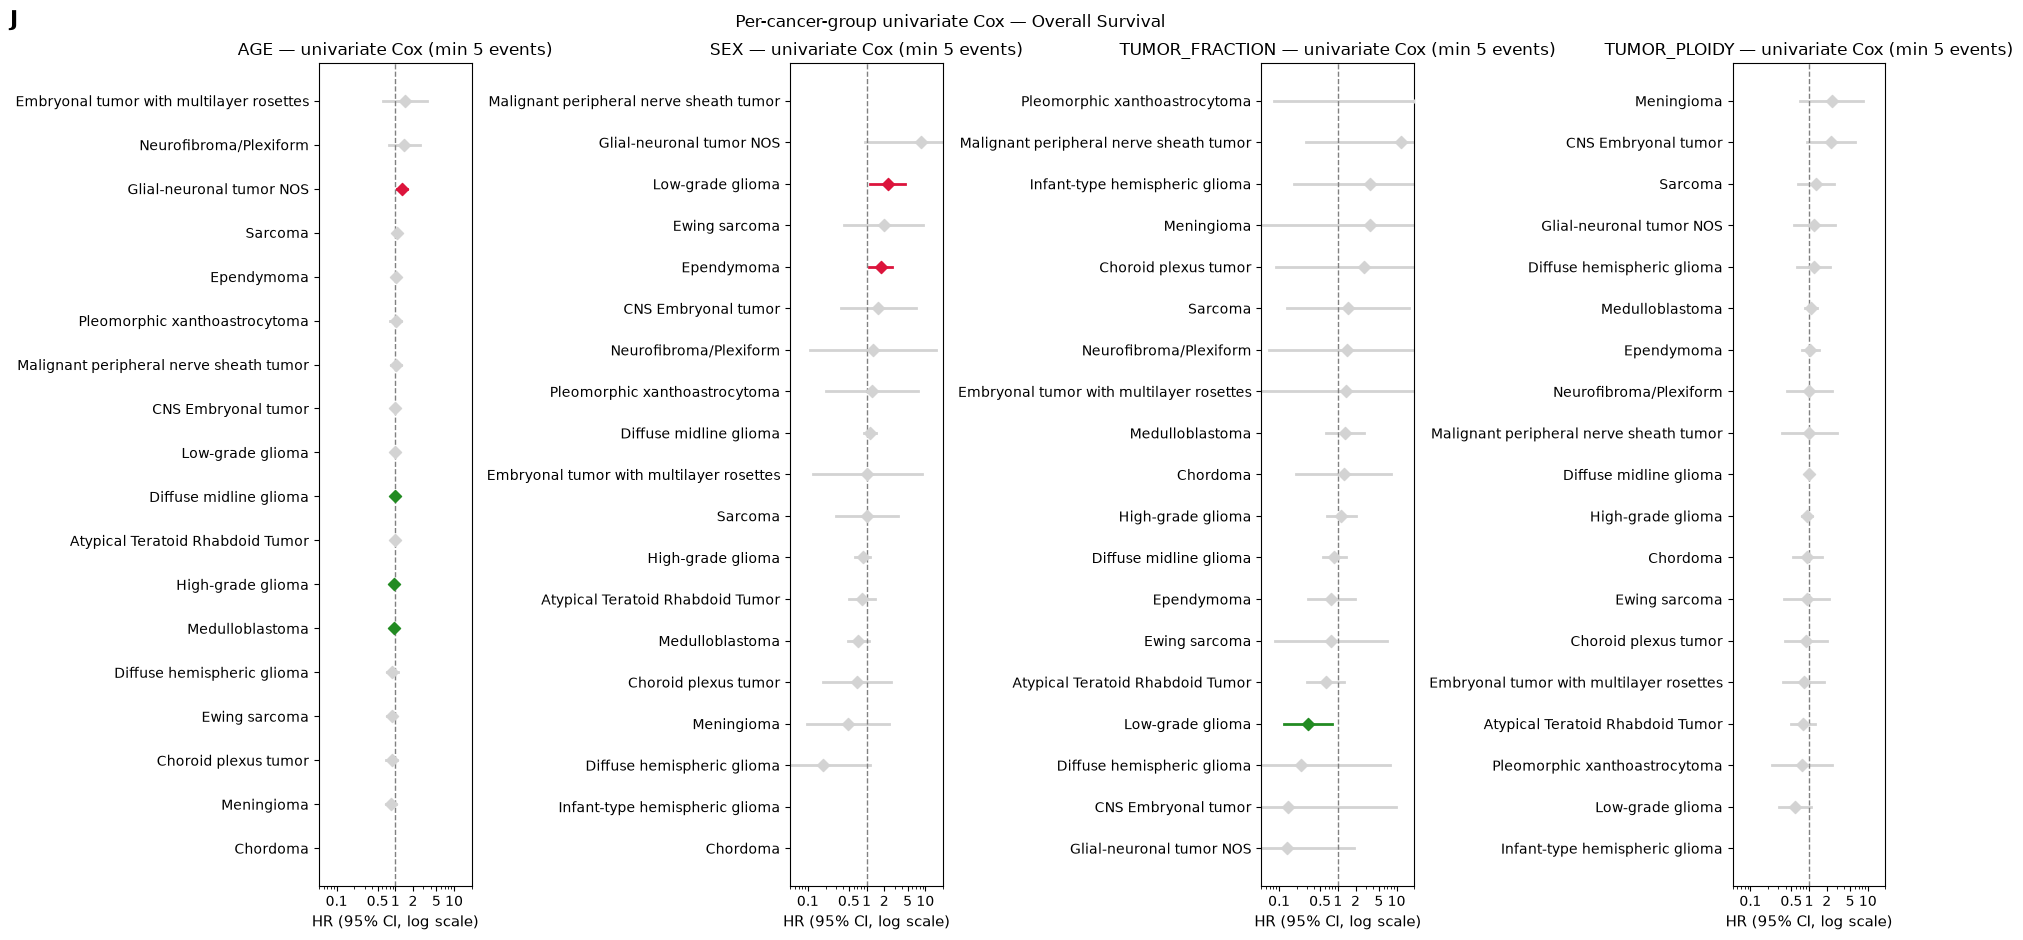

In [10]:
# Panel 4.J — Per-cancer-group univariate Cox — Overall Survival
# Mirrors clinical_mulltivar_hidden_strcture_analysis cells 13/14 (subgroup_forest).
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.J")
predictors = ["AGE", "SEX", "TUMOR_FRACTION", "TUMOR_PLOIDY"]
coxd = df.dropna(subset=["OS_MONTHS", "os_event"] + predictors).copy()
print(f"OS per-CG univariate Cox: {len(coxd)} samples, {int(coxd['os_event'].sum())} events")
fig, axes = plt.subplots(1, len(predictors), figsize=(19, 9.5))
fig.text(0.005, 0.985, "J", fontsize=16, fontweight="bold", va="top", ha="left")
subgroup_forest_mpl(axes, coxd, "OS_MONTHS", "os_event", predictors)
fig.suptitle("Per-cancer-group univariate Cox — Overall Survival", fontsize=12)
fig.tight_layout()
plt.show()


4.K
EFS per-CG univariate Cox: 2147 samples, 1384 events


  [AGE] 30 CGs fitted, 8 significant:
    Embryonal tumor with multilayer rosettes: HR=0.221 (0.068-0.723) p=0.0125 n=12 events=10
    Choroid plexus tumor: HR=0.855 (0.738-0.990) p=0.0362 n=58 events=18
    Meningioma: HR=0.901 (0.843-0.962) p=0.0018 n=62 events=39
    Ganglioglioma: HR=0.914 (0.856-0.975) p=0.0068 n=82 events=37
    Low-grade glioma: HR=0.935 (0.908-0.963) p=0.0000 n=438 events=224
    Medulloblastoma: HR=0.957 (0.924-0.991) p=0.0132 n=289 events=133
    High-grade glioma: HR=0.957 (0.937-0.979) p=0.0001 n=197 events=175
    Ependymoma: HR=0.968 (0.937-1.000) p=0.0477 n=200 events=137


  [SEX] 30 CGs fitted, 1 significant:
    Diffuse midline glioma: HR=0.730 (0.559-0.953) p=0.0207 n=236 events=232


  [TUMOR_FRACTION] 31 CGs fitted, 2 significant:
    Ganglioneuroblastoma: HR=0.001 (0.000-0.592) p=0.0349 n=7 events=7
    Adamantinomatous Craniopharyngioma: HR=3.523 (1.227-10.117) p=0.0193 n=71 events=47


  [TUMOR_PLOIDY] 31 CGs fitted, 2 significant:
    Schwannoma: HR=2.237 (1.109-4.510) p=0.0245 n=34 events=20
    Embryonal tumor with multilayer rosettes: HR=2.487 (1.073-5.762) p=0.0336 n=12 events=10


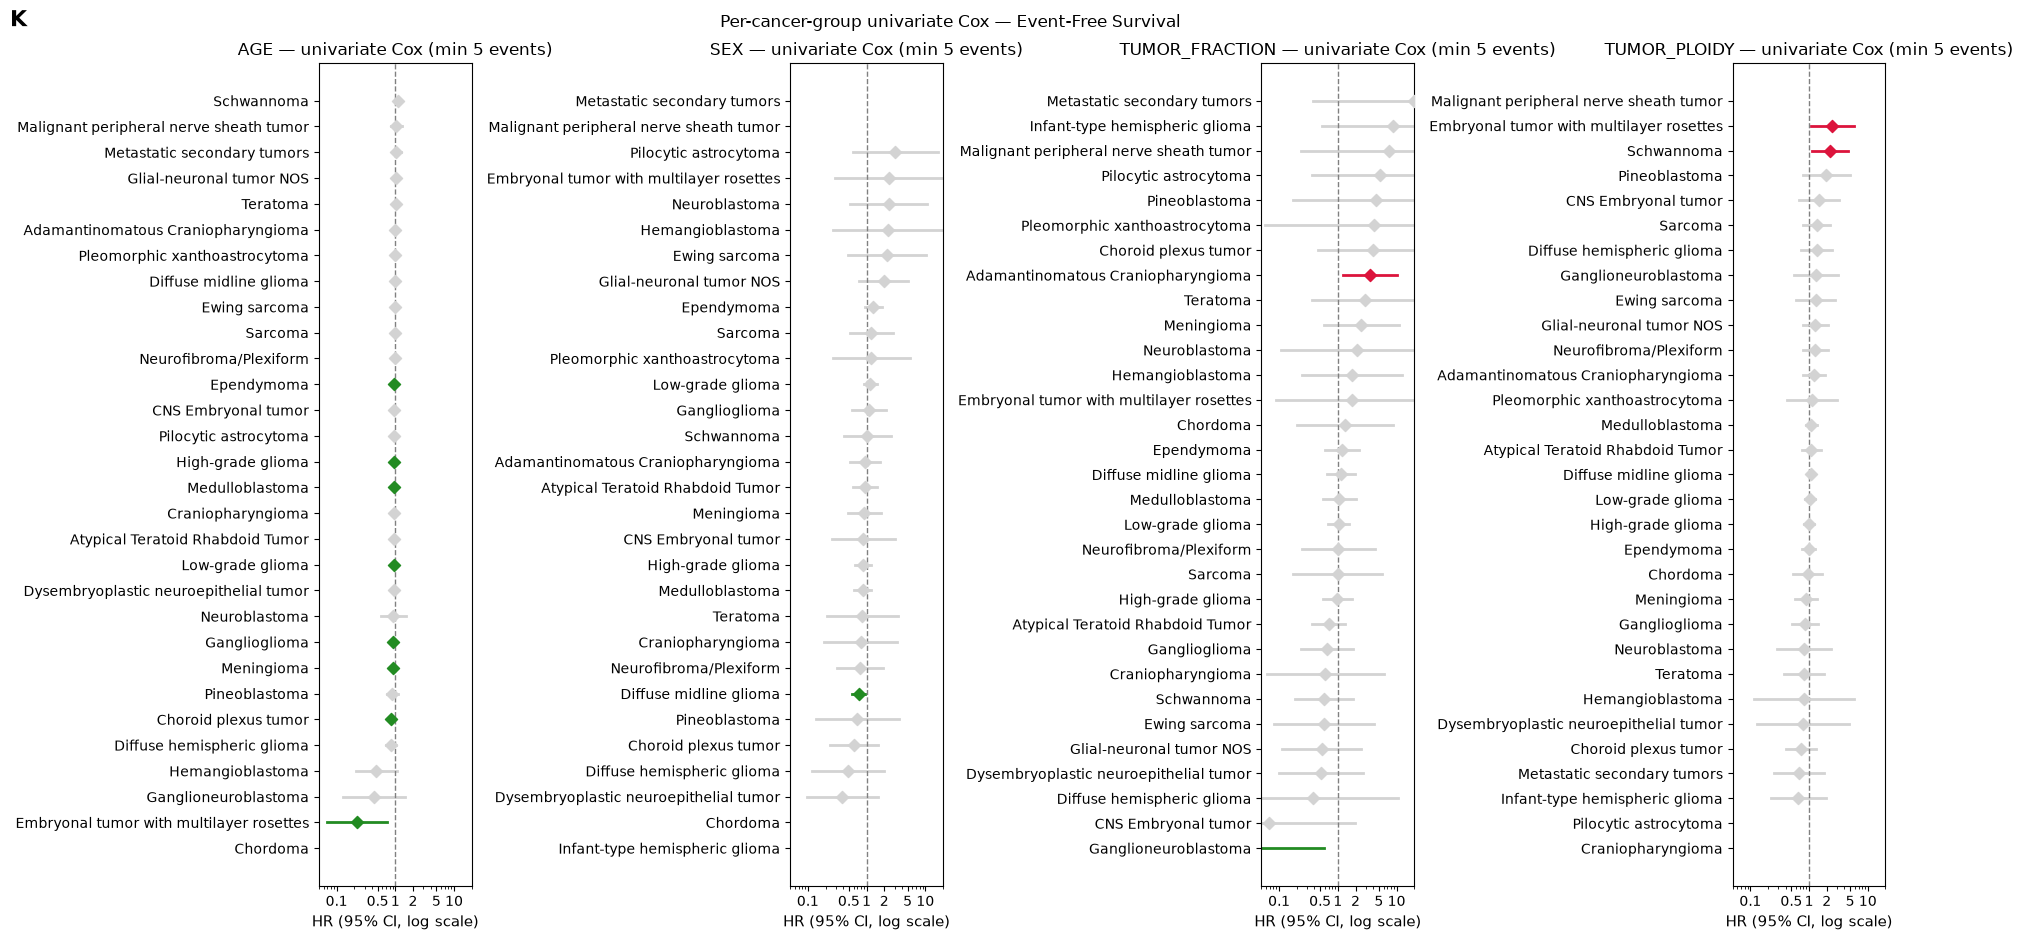

In [11]:
# Panel 4.K — Per-cancer-group univariate Cox — Event-Free Survival
# Mirrors clinical_mulltivar_hidden_strcture_analysis cells 13/14 (subgroup_forest).
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from lifelines import CoxPHFitter
import warnings

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"

def read_patients():
    return pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                       dtype={"AGE": float, "AGE_IN_DAYS": float,
                              "OS_MONTHS": float, "EFS_MONTHS": float})

def read_samples():
    return pd.read_csv(SAMPLE_FILE, sep="\t", header=4)

def clean_os(d):
    d = d.copy()
    d["OS_STATUS"] = d["OS_STATUS"].str.strip()
    d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
    d["os_event"] = d["OS_STATUS"].apply(
        lambda x: 1 if pd.notna(x) and x.startswith("1:") else (0 if pd.notna(x) and x.startswith("0:") else np.nan))
    return d

def clean_efs(d):
    d = d.copy()
    d["EFS_STATUS"] = d["EFS_STATUS"].str.strip()
    d["efs_event"] = d["EFS_STATUS"].apply(
        lambda x: 0 if pd.notna(x) and x == "0:No Event" else (1 if pd.notna(x) and x != "1:NA" else np.nan))
    return d

def clean_pred(d):
    d = d.copy()
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].fillna("Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
    d["CANCER_PREDISPOSITIONS"] = d["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
    return d

# Load + clean once; later cells reuse `df` from the kernel (guard keeps each
# cell runnable in isolation while avoiding re-reading the data on full runs).
if "df" not in globals():
    pat = read_patients(); smp = read_samples()
    pat = clean_os(pat); pat = clean_efs(pat); pat = clean_pred(pat)
    df = smp.merge(pat, on="PATIENT_ID", how="left")
    df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"].astype(str).str.strip() != "")].copy()
    for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS"]:
        df[col] = df[col].astype(str)

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi) / (n_x * n_y)
    less = sum(1 for xi in x for yi in y if xi < yi) / (n_x * n_y)
    return more - less

def cramers_v(ct):
    chi2v = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2v / n
    r, k = ct.shape
    return float(np.sqrt(phi2 / min(k - 1, r - 1)))

def kaplan_meier(times, events):
    d = pd.DataFrame({"t": times, "e": events}).dropna().sort_values("t")
    surv = 1.0
    n = len(d)
    res = []
    for t, grp in d.groupby("t", sort=False):
        ne = int(grp["e"].sum())
        if ne > 0:
            surv *= (1 - ne / n)
        res.append({"t": t, "s": surv, "n": n, "ne": ne})
        n -= len(grp)
    return pd.DataFrame(res)

def plot_km(ax, km, color, lw=1.8, label=None):
    t = np.concatenate([[0.0], km["t"].values])
    s = np.concatenate([[1.0], km["s"].values])
    ax.step(t, s, where="post", color=color, lw=lw, label=label)

def logrank2(t1, e1, t2, e2):
    from scipy.stats import chi2
    all_t = sorted(set(pd.concat([pd.Series(t1.dropna()), pd.Series(t2.dropna())]).dropna()))
    if len(all_t) < 2:
        return 1.0
    o1e = 0; v = 0
    d1 = pd.DataFrame({"t": t1, "e": e1}).dropna()
    d2 = pd.DataFrame({"t": t2, "e": e2}).dropna()
    for t in all_t:
        r1 = (d1["t"] >= t).sum(); r2 = (d2["t"] >= t).sum(); nr = r1 + r2
        if nr == 0: continue
        o1 = int(((d1["t"] == t) & (d1["e"] == 1)).sum())
        o2 = int(((d2["t"] == t) & (d2["e"] == 1)).sum())
        ot = o1 + o2
        if ot == 0: continue
        e1 = ot * r1 / nr; o1e += (o1 - e1)
        if nr > 1:
            v += ot * (r1 / nr) * (r2 / nr) * (nr - ot) / (nr - 1)
    if v <= 0:
        return 1.0
    return 1 - chi2.cdf(o1e ** 2 / v, 1)

def logrank_multi(groups):
    from scipy.stats import chi2
    ng = len(groups)
    if ng < 2:
        return 1.0
    all_t = sorted(set(pd.concat([pd.Series(g[0].dropna()) for g in groups]).dropna()))
    if len(all_t) < 2:
        return 1.0
    O = np.zeros(ng); E = np.zeros(ng); V = np.zeros((ng, ng))
    for t in all_t:
        ar = np.array([(g[0] >= t).sum() for g in groups]); nr = ar.sum()
        if nr == 0: continue
        ev = np.array([((g[0] == t) & (g[1] == 1)).sum() for g in groups]); ot = ev.sum()
        if ot == 0: continue
        O += ev; E += ot * ar / nr
        if nr > 1:
            for i in range(ng):
                for j in range(ng):
                    if i == j:
                        V[i, j] += ot * ar[i] / nr * (1 - ar[i] / nr) * (nr - ot) / (nr - 1)
                    else:
                        V[i, j] -= ot * ar[i] / nr * ar[j] / nr * (nr - ot) / (nr - 1)
    try:
        return 1 - chi2.cdf((O - E) @ np.linalg.pinv(V) @ (O - E), ng - 1)
    except Exception:
        return 1.0

def status_box(ax, col, xlabel, outcome, data=None):
    src = df if data is None else data
    if outcome == "OS":
        d = src.dropna(subset=[col, "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        g0 = d[d["os_label"] == "LIVING"][col]
        g1 = d[d["os_label"] == "DECEASED"][col]
        lab0, lab1, c0, c1 = "LIVING", "DECEASED", "#2ecc71", "#e74c3c"
    else:
        d = src.dropna(subset=[col, "efs_event"]).copy()
        g0 = d[d["efs_event"] == 0][col]
        g1 = d[d["efs_event"] == 1][col]
        lab0, lab1, c0, c1 = "No Event", "Event", "#3498db", "#e67e22"
    u, p = mannwhitneyu(g0, g1, alternative="two-sided")
    eff = cliffs_delta(g0.values, g1.values)
    print(f"{col} x {outcome}: U={u:.0f} p={p:.4f} d={eff:.3f} N={len(g0)+len(g1)}")
    bp = ax.boxplot([g0, g1], tick_labels=[lab0, lab1], patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="black", lw=1.3),
                    whiskerprops=dict(color="0.25", lw=0.9),
                    capprops=dict(color="0.25", lw=0.9),
                    boxprops=dict(lw=0.9))
    for patch, cc in zip(bp["boxes"], [c0, c1]):
        patch.set_facecolor(cc); patch.set_alpha(0.55)
    for i, g in enumerate([g0, g1]):
        rng = np.random.default_rng(7 + i)
        ax.scatter(i + 1 + rng.uniform(-0.12, 0.12, len(g)), g, s=8, alpha=0.3,
                   color=[c0, c1][i], zorder=3)
    ax.set_xlabel(outcome + " status")
    ax.set_ylabel(xlabel)
    ax.set_title(f"{col} x {outcome} — U={u:.0f}, p={p:.4f}, d={eff:.3f}", fontsize=10)

def sex_bar(ax, outcome):
    if outcome == "OS":
        d = df.dropna(subset=["SEX", "OS_STATUS"]).copy()
        d["os_label"] = d["OS_STATUS"].str.replace(r"^\d+:", "", regex=True)
        cmap = {"LIVING": "#2ecc71", "DECEASED": "#e74c3c"}
    else:
        d = df.dropna(subset=["SEX", "efs_event"]).copy()
        d["os_label"] = d["efs_event"].map({0: "No Event", 1: "Event"})
        cmap = {"No Event": "#3498db", "Event": "#e67e22"}
    ct = pd.crosstab(d["SEX"], d["os_label"])
    chi2v, pv, dof, exp = chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"SEX x {outcome}: chi2={chi2v:.2f} p={pv:.4f} V={v:.3f} N={len(d)}")
    xpos = np.arange(len(ct.index))
    width = 0.8 / max(len(ct.columns), 1)
    for j, c in enumerate(ct.columns):
        col = cmap.get(c, "0.75")
        ax.bar(xpos + (j - (len(ct.columns) - 1) / 2) * width, ct[c].values, width,
               color=col, label=c, edgecolor="white", lw=0.4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(ct.index)
    ax.set_xlabel("SEX")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"SEX x {outcome} — χ²={chi2v:.2f}, p={pv:.4f}, V={v:.3f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8)

def km_mini(ax, g1, g2, time_col, event_col, lab1, lab2, col1, col2, title, subletter, ylab):
    p = logrank2(g1[time_col], g1[event_col], g2[time_col], g2[event_col])
    km = kaplan_meier(g1[time_col], g1[event_col])
    plot_km(ax, km, col1, label=f"{lab1} (n={len(g1)})")
    km = kaplan_meier(g2[time_col], g2[event_col])
    plot_km(ax, km, col2, label=f"{lab2} (n={len(g2)})")
    sig = p < 0.05
    ax.set_xlabel("Months", fontsize=11)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{title} — log-rank p={p:.4f}{'' if sig else ' (ns)'}",
                 fontsize=12, fontweight="bold" if sig else "normal")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.text(0.0, 1.0, subletter, transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", bbox=dict(facecolor="white", alpha=0.6,
                                           edgecolor="none", pad=0.5))
    return p

def forest_panel(cph, title, metrics, panel_letter):
    from matplotlib.lines import Line2D
    label_map = {"C(SEX)[T.Male]": "SEX (Male)",
                 "C(SEX)[T.Not Reported]": "SEX (Not Reported)",
                 "C(SEX)[T.nan]": "SEX (nan)"}
    rows = []
    for var in cph.params_.index:
        if var.startswith("CANCER_GROUP"):
            continue
        hr = float(np.exp(cph.params_[var]))
        ci = np.exp(cph.confidence_intervals_.loc[var])
        pv = float(cph.summary.loc[var, "p"])
        rows.append({"label": label_map.get(var, var), "hr": hr,
                     "ci_lower": float(ci.iloc[0]), "ci_upper": float(ci.iloc[1]),
                     "p_value": pv})
    for r in rows:
        print(f"  {r['label']:<20s} HR={r['hr']:.4f} ({r['ci_lower']:.4f}-{r['ci_upper']:.4f}) p={r['p_value']:.4f}")
    def row_color(r):
        if r["p_value"] < 0.05:
            return "forestgreen" if r["hr"] < 1 else "crimson"
        return "lightgray"
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ypos = np.arange(len(rows))
    for yi, r in zip(ypos, rows):
        c = row_color(r)
        ax.plot([r["ci_lower"], r["ci_upper"]], [yi, yi], color=c, lw=2.2, zorder=2)
        ax.scatter([r["hr"]], [yi], marker="D", s=50, color=c, zorder=3)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.text(1.0, len(rows) - 0.35, "HR=1", ha="center", fontsize=7, color="gray")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 10)
    ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2", "5", "10"])
    ax.set_yticks(ypos)
    ax.set_yticklabels([r["label"] for r in rows], fontsize=9)
    def fmt_p(p):
        return "p<0.001" if p < 0.001 else f"p={p:.3f}"
    for yi, r in zip(ypos, rows):
        ax.text(1.01, yi, f"HR {r['hr']:.2f} ({r['ci_lower']:.2f}-{r['ci_upper']:.2f})  {fmt_p(r['p_value'])}",
                transform=ax.get_yaxis_transform(), va="center", ha="left", fontsize=8)
    ax.set_xlabel("Hazard ratio (95% CI, log scale)")
    ax.set_title(f"{title}\nStratified by CANCER_GROUP", fontsize=10)
    handles = [Line2D([0], [0], marker="D", color="w", markerfacecolor="forestgreen", markersize=8, label="sig, HR<1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="crimson", markersize=8, label="sig, HR>1"),
               Line2D([0], [0], marker="D", color="w", markerfacecolor="lightgray", markersize=8, label="ns (p>=0.05)")]
    ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8)
    ax.text(0.0, -0.22, metrics, transform=ax.transAxes, fontsize=8, va="top")
    fig.text(0.005, 0.95, panel_letter, fontsize=15, fontweight="bold", va="top", ha="left")
    fig.subplots_adjust(left=0.24, right=0.55, top=0.84, bottom=0.14)
    plt.show()

def subgroup_forest_mpl(axes, coxd, outcome_col, event_col, predictors, min_events=5):
    """Per-cancer-group univariate Cox forest (matplotlib port of subgroup_forest
    in clinical_mulltivar_hidden_strcture_analysis). One panel per predictor."""
    for ax, pred in zip(axes, predictors):
        results = []
        for cg in sorted(coxd["CANCER_GROUP"].unique()):
            sub = coxd[coxd["CANCER_GROUP"] == cg].dropna(subset=[outcome_col, event_col, pred])
            if int(sub[event_col].sum()) < min_events:
                continue
            if pred == "SEX":
                sexes = sub["SEX"].dropna().unique()
                if len(sexes) < 2:
                    continue
                sub = sub[sub["SEX"].isin(sexes)]
            try:
                with warnings.catch_warnings():
                    # Convergence/overflow warnings are expected for tiny per-CG fits.
                    warnings.simplefilter("ignore")
                    cph = CoxPHFitter()
                    formula = "C(SEX)" if pred == "SEX" else pred
                    cph.fit(sub, duration_col=outcome_col, event_col=event_col, formula=formula)
                    hr = float(np.exp(cph.params_.iloc[0]))
                    ci = np.exp(cph.confidence_intervals_.iloc[0])
                    p = float(cph.summary["p"].iloc[0])
            except Exception:
                continue
            results.append({"cg": cg, "hr": hr, "lo": float(ci.iloc[0]), "hi": float(ci.iloc[1]),
                            "p": p, "n": len(sub), "ev": int(sub[event_col].sum())})
        if not results:
            ax.axis("off")
            ax.set_title(f"{pred} — no data", fontsize=10)
            continue
        res = pd.DataFrame(results).sort_values("hr")
        ypos = np.arange(len(res))
        for yi, r in zip(ypos, res.to_dict("records")):
            c = "forestgreen" if (r["p"] < 0.05 and r["hr"] < 1) else                 "crimson" if (r["p"] < 0.05 and r["hr"] > 1) else "lightgray"
            ax.plot([r["lo"], r["hi"]], [yi, yi], color=c, lw=2.0, zorder=2)
            ax.scatter([r["hr"]], [yi], marker="D", s=38, color=c, zorder=3)
        ax.axvline(1.0, color="gray", ls="--", lw=1)
        ax.set_xscale("log")
        ax.set_xlim(0.05, 20)
        ax.set_xticks([0.1, 0.5, 1, 2, 5, 10])
        ax.set_xticklabels(["0.1", "0.5", "1", "2", "5", "10"], fontsize=10)
        ax.set_yticks(ypos)
        ax.set_yticklabels([r["cg"] for r in res.to_dict("records")], fontsize=10)
        ax.set_title(f"{pred} — univariate Cox (min {min_events} events)", fontsize=12)
        ax.set_xlabel("HR (95% CI, log scale)", fontsize=11)
        print(f"  [{pred}] {len(res)} CGs fitted, {(res['p'] < 0.05).sum()} significant:")
        for _, r in res[res["p"] < 0.05].iterrows():
            print(f"    {r['cg']}: HR={r['hr']:.3f} ({r['lo']:.3f}-{r['hi']:.3f}) "
                  f"p={r['p']:.4f} n={int(r['n'])} events={int(r['ev'])}")


print("4.K")
predictors = ["AGE", "SEX", "TUMOR_FRACTION", "TUMOR_PLOIDY"]
coxd = df.dropna(subset=["EFS_MONTHS", "efs_event"] + predictors).copy()
print(f"EFS per-CG univariate Cox: {len(coxd)} samples, {int(coxd['efs_event'].sum())} events")
fig, axes = plt.subplots(1, len(predictors), figsize=(19, 9.5))
fig.text(0.005, 0.985, "K", fontsize=16, fontweight="bold", va="top", ha="left")
subgroup_forest_mpl(axes, coxd, "EFS_MONTHS", "efs_event", predictors)
fig.suptitle("Per-cancer-group univariate Cox — Event-Free Survival", fontsize=12)
fig.tight_layout()
plt.show()
